Dataset Shape: (1000, 10)

Columns: Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car



Target Column Used: Purpose
Unique Target Values: [0 1 2 3 4 5 6 7]
After SMOTE: [337 337 337 337 337 337 337 337]

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.34      0.26      0.29        81
           1       0.12      0.03      0.05        69
           2       0.29      0.65      0.41        63
           3       0.29      0.17      0.22        64
           4       0.31      0.33      0.32        55
           5       0.17      0.13      0.15        69
           6       0.26      0.29      0.27        73
           7       0.53      0.73      0.61        66

    accuracy                           0.32       540
   macro avg       0.29      0.32      0.29       540
weighted avg       0.29      0.32      0.29       540

Confusion Matrix:
 [[21  2 17  4  5 16  7  9]
 [ 4  2 16  3 13  4 14 13]
 [ 1  0 41  3  1 11  6  0]
 [ 5  0 20 11  6  1 14  7]
 [ 8  1  7  2 18  3 12  4]
 [12  4 18  6 12  9  5  3]
 [ 9  7 18  1  3  7

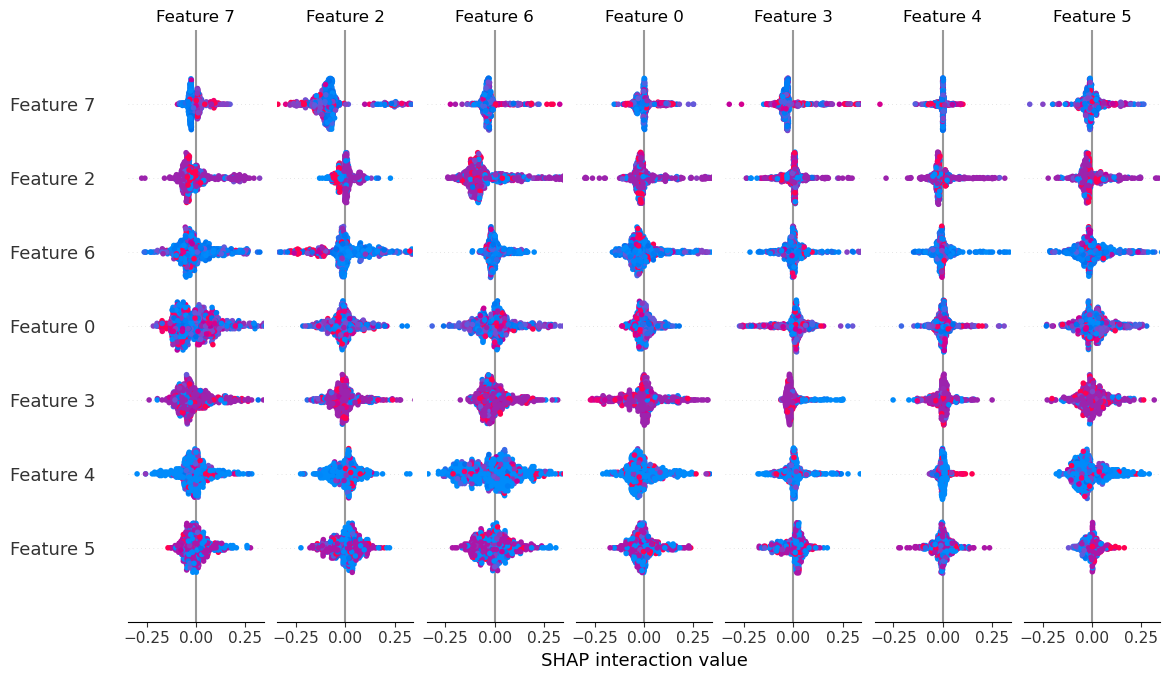


Generating LIME Explanation...


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import shap
from lime.lime_tabular import LimeTabularExplainer


%matplotlib inline


df = pd.read_csv("german_credit_data.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

display(df.head())



if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


df = df.ffill()


le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


y = df.iloc[:, -1]
X = df.iloc[:, :-1]

print("\nTarget Column Used:", df.columns[-1])

if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

print("Unique Target Values:", np.unique(y))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("After SMOTE:", np.bincount(y_res))

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)



lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5)
rf = RandomForestClassifier(n_estimators=100)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)



def evaluate(model, name):
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

   
    try:
        if len(np.unique(y_test)) == 2:
            y_prob = model.predict_proba(X_test)[:, 1]
            print("ROC-AUC:", roc_auc_score(y_test, y_prob))
        else:
            y_prob = model.predict_proba(X_test)
            print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))
    except:
        print("ROC-AUC not available")


evaluate(lr, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")


print("\nGenerating SHAP Plot...")

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)


print("\nGenerating LIME Explanation...")

explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=[f'Feature {i}' for i in range(X_train.shape[1])],
    class_names=[str(c) for c in np.unique(y)],
    mode='classification'
)

exp = explainer_lime.explain_instance(
    X_test[0],
    rf.predict_proba
)

exp.show_in_notebook(show_table=True)